[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Introduction Fourier Series

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# we rather use definition sinc(x) = sin(x)/x
def my_sinc(x):  
    return np.sinc(x/np.pi)

In [2]:
T = 2  # signal period in s
# max k in Fourier series
K_des = [40, 40, 40, 40, 40]
# signal high duration per period, <=T
Th_des = [0.1*T, 0.2*T, 0.5*T, 0.8*T, T]

0 40 0.2
imag of x must be around 1e-16 due to numerical precision errors 7.4593109467002705e-16
1 40 0.4
imag of x must be around 1e-16 due to numerical precision errors 3.95516952522712e-16
2 40 1.0
imag of x must be around 1e-16 due to numerical precision errors 1.3357370765021415e-16
3 40 1.6
imag of x must be around 1e-16 due to numerical precision errors 1.0668549377257364e-16
4 40 2
imag of x must be around 1e-16 due to numerical precision errors 1.8536908614779343e-17


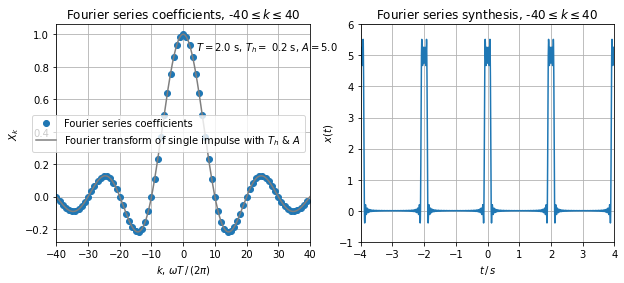

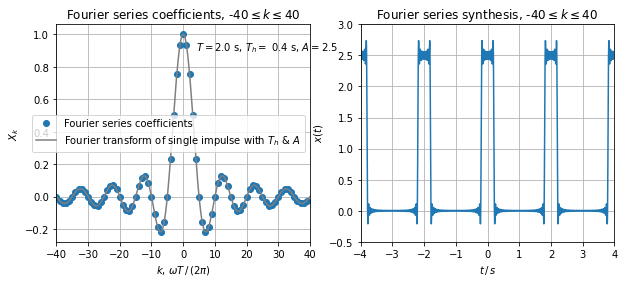

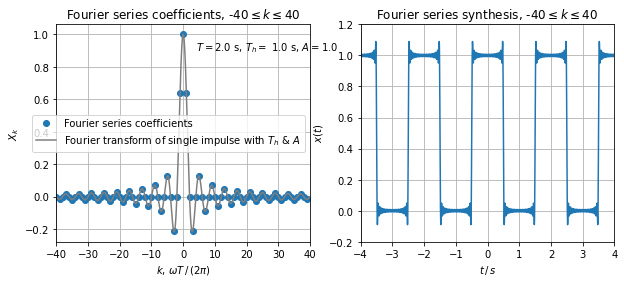

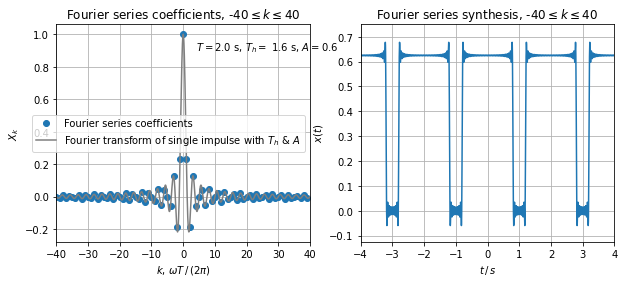

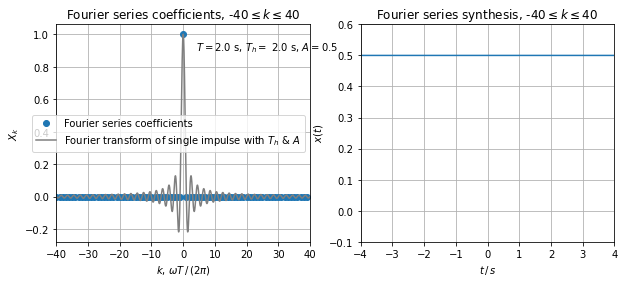

In [3]:
for idx, (K, Th) in enumerate(zip(K_des, Th_des)):
    print(idx, K, Th)

    A = 1 / Th  # such that sinc amplitude is always 1 for ck*T

    # Fourier series coefficients
    # are real due to axial symmetry of x(t)
    w0 = 2*np.pi / T
    k = np.arange(-K, K)
    Xk = A*Th * my_sinc(w0*k*Th/2)

    # Fourier transform for single rect pulse
    w = w0 * np.linspace(-K, K, K * 2**8, endpoint=True)
    X = A*Th * my_sinc(w*Th/2)

    # time vector
    fh = w0*K / (2*np.pi)  # highest frequency in the signal
    fs = 10*fh  # sampling frequency, >2*fh according to sampling theorem
    Ts = 1/fs  # sampling period
    tmin = -2*T
    tmax = +2*T
    trange = tmax - tmin
    t = np.arange(np.int32(trange/Ts))*Ts + tmin

    # Fourier series synthesis
    x = 1/T * np.sum(Xk[:, np.newaxis] *
                     np.exp(+1j*w0*k[:, np.newaxis]*t[np.newaxis, :]), axis=0)
    print('imag of x must be around 1e-16 due to numerical precision errors',
          np.max(np.abs(np.imag(x))))  # very small, thus:
    x = np.real_if_close(x)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(k, Xk, 'C0o', label='Fourier series coefficients')
    plt.plot(w*T/(2*np.pi), X, 'C7',
             label='Fourier transform of single impulse with $T_h$ & $A$')
    plt.xlim(-K, +K)
    plt.xlabel(r'$k$, $\omega T \, / \, (2\pi)$')
    plt.ylabel(r'$X_k$')
    plt.title(r'Fourier series coefficients, %d$\leq k \leq $%d' % (-K, +K))
    plt.legend()
    plt.text(K/10, 0.9, r'$T=$%3.1f s, $T_h=$ %3.1f s, $A=$%3.1f' % (T, Th, A))
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(t, x)
    plt.xticks(np.arange(tmin, tmax+T/2, T/2))
    plt.xlim(tmin, tmax)
    plt.ylim(-1/5*A, 6/5*A)
    plt.xlabel(r'$t \, / \, s$')
    plt.ylabel(r'$x(t)$')
    plt.title(r'Fourier series synthesis, %d$\leq k \leq $%d' % (-K, +K))
    plt.grid(True)
    plt.savefig('D1483A84E2_'+str(idx)+'.pdf')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.